# DistilBERT for NER



In [1]:
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForTokenClassification,
    get_linear_schedule_with_warmup,
)
from seqeval.metrics import (
    classification_report,
    f1_score, precision_score, recall_score,
)
# check for device GPU(useful for local training)
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13})
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU   : {torch.cuda.get_device_name(0)}')

/mnt/windows/wheelchair-dev/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
GPU   : NVIDIA GeForce RTX 3050 Laptop GPU


### Load Data & Vocab

In [2]:
data_dir  = Path('../../datasets/processed_data')
split_dir = Path('../../datasets/split_data')
subword_dir = Path('../') 


with open(subword_dir / 'subword_bio.json') as f:
    subword_data = json.load(f) 

with open(data_dir / 'vocabs.pkl', 'rb') as f:
    v = pickle.load(f)
    label2id      = v['label2id']
    id2label      = v['id2label']
    Entity_labels = v['Entity_labels']
    MAX_LEN_BERT  = v['MAX_LEN_BERT']

with open(split_dir / 'split_indices.json') as f:
    split = json.load(f)
idx_train = split['idx_train']
idx_val   = split['idx_val']
idx_test  = split['idx_test']

print(f'Train: {len(idx_train)} | Val: {len(idx_val)} | Test: {len(idx_test)}')
print(f'Labels ({len(label2id)}): {sorted(label2id.keys())}')
print(f'MAX_LEN_BERT: {MAX_LEN_BERT}')
print(f'Subword resumes loaded: {len(subword_data)}')

Train: 154 | Val: 33 | Test: 33
Labels (22): ['<PAD_LABEL>', 'B-College Name', 'B-Companies worked at', 'B-Degree', 'B-Designation', 'B-Email Address', 'B-Graduation Year', 'B-Location', 'B-Name', 'B-Skills', 'B-Years of Experience', 'I-College Name', 'I-Companies worked at', 'I-Degree', 'I-Designation', 'I-Email Address', 'I-Graduation Year', 'I-Location', 'I-Name', 'I-Skills', 'I-Years of Experience', 'O']
MAX_LEN_BERT: 512
Subword resumes loaded: 220


### Tokenizer & Label Alignment


In [3]:
MODEL_NAME = 'distilbert-base-uncased'
tokenizer  = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)


def align_labels_chunked(tokens, tags, tokenizer, max_len, label2id, stride=128):
    enc = tokenizer(
        tokens,
        is_split_into_words=True,
        max_length=max_len,
        truncation=True,
        stride=stride,
        return_overflowing_tokens=True,
        padding='max_length',
        return_tensors=None,
    )

    all_chunks = []
    for chunk_idx in range(len(enc['input_ids'])):
        word_ids = enc.word_ids(chunk_idx)
        label_ids = []
        prev_word_idx = None
        for wid in word_ids:
            if wid is None:
                label_ids.append(-100)
            elif wid != prev_word_idx:
                label_ids.append(label2id.get(tags[wid], label2id.get('O', 0)))
            else:
                label_ids.append(-100)
            prev_word_idx = wid

        all_chunks.append({
            'input_ids'      : torch.tensor(enc['input_ids'][chunk_idx],      dtype=torch.long),
            'attention_mask' : torch.tensor(enc['attention_mask'][chunk_idx], dtype=torch.long),
            'labels'         : torch.tensor(label_ids,                        dtype=torch.long),
        })

    return all_chunks



demo_chunks = align_labels_chunked(
    subword_data[0]['tokens'], subword_data[0]['tags'], tokenizer, MAX_LEN_BERT, label2id
)
print(f'Resume 0 : {len(demo_chunks)} chunk(s)')
print('input_ids (first 15) :', demo_chunks[0]['input_ids'][:15].tolist())
print('labels    (first 15) :', demo_chunks[0]['labels'][:15].tolist())

Resume 0 : 1 chunk(s)
input_ids (first 15) : [101, 11113, 24158, 5369, 2243, 1046, 3270, 4646, 2458, 5482, 9669, 5397, 8191, 1001, 1001]
labels    (first 15) : [-100, 2, -100, -100, -100, 3, -100, 4, 5, 5, 6, -100, 1, 1, -100]


### Dataset & DataLoaders

In [4]:
class NERDataset(Dataset):
    def __init__(self, indices, subword_data, tokenizer, max_len, label2id, stride=128):
        self.samples = []
        for i in indices:
            entry  = subword_data[i]
            chunks = align_labels_chunked(
                entry['tokens'], entry['tags'], tokenizer, max_len, label2id, stride
            )
            self.samples.extend(chunks)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]


BATCH_SIZE = 8

train_dataset = NERDataset(idx_train, subword_data, tokenizer, MAX_LEN_BERT, label2id)
val_dataset   = NERDataset(idx_val,   subword_data, tokenizer, MAX_LEN_BERT, label2id)
test_dataset  = NERDataset(idx_test,  subword_data, tokenizer, MAX_LEN_BERT, label2id)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE)

print(f'Train samples (chunks): {len(train_dataset)}')
print(f'Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')

Train samples (chunks): 298
Train batches: 38 | Val: 10 | Test: 9


### Model

In [5]:
model = DistilBertForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label2id),
    id2label={int(k): v for k, v in id2label.items()},
    label2id=label2id,
).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params    : {total_params:,}')
print(f'Trainable params: {trainable_params:,}')

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 9186.35it/s]
[transformers] DistilBertForTokenClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total params    : 66,379,798
Trainable params: 66,379,798


### Hyperparameters

In [6]:
NUM_EPOCHS    = 50
LR            = 2e-5
WARMUP_RATIO  = 0.1
PATIENCE      = 5       # early stopping patience (val F1)

total_steps   = len(train_loader) * NUM_EPOCHS
warmup_steps  = int(total_steps * WARMUP_RATIO)

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

print(f'Total steps : {total_steps} | Warmup steps: {warmup_steps}')

Total steps : 1900 | Warmup steps: 190


### Helper — Decode Predictions

Converts logits back to BIO tag sequences


In [7]:
def decode_preds(logits, label_ids, id2label):

    preds = logits.argmax(dim=-1).cpu().numpy()   # (batch, seq)
    refs  = label_ids.cpu().numpy()               # (batch, seq)

    y_true, y_pred = [], []
    for pred_seq, ref_seq in zip(preds, refs):
        true_row, pred_row = [], []
        for p, r in zip(pred_seq, ref_seq):
            if r == -100:
                continue
            true_row.append(id2label[r])
            pred_row.append(id2label[p])
        y_true.append(true_row)
        y_pred.append(pred_row)
    return y_true, y_pred

In [8]:
# handling class imbalance
from torch import nn
from collections import Counter  
import torch
# Count label frequencies across training set
label_counts = Counter()
for sample in train_dataset:
    for lid in sample['labels'].tolist():
        if lid != -100:
            label_counts[lid] += 1

total = sum(label_counts.values())
num_labels = len(label2id)

weights = []
for i in range(num_labels):
    count = label_counts.get(i, 1)
    w = total / (num_labels * count)
    weights.append(w)


O_idx = label2id['O']
weights[O_idx] = min(weights[O_idx], 0.1)
weights = [min(w, 10.0) for w in weights]   


loss_fn = nn.CrossEntropyLoss(ignore_index=-100)

print("Class weights (top 10 by weight):")
sorted_w = sorted(enumerate(weights), key=lambda x: -x[1])
for idx, w in sorted_w[:10]:
    print(f"  {id2label[idx]:<30} {w:.4f}")

Class weights (top 10 by weight):
  <PAD_LABEL>                    10.0000
  B-Name                         10.0000
  I-Name                         10.0000
  B-Designation                  10.0000
  I-Companies worked at          10.0000
  B-Location                     10.0000
  I-Location                     10.0000
  B-Email Address                10.0000
  I-Email Address                10.0000
  B-College Name                 10.0000


### Training

In [9]:
model_save_dir = Path('./model_result')
model_save_dir.mkdir(exist_ok=True)
BEST_CKPT = model_save_dir / 'distilbert_best.pt'

history = []
best_val_f1   = 0.0
patience_ctr  = 0

for epoch in range(1, NUM_EPOCHS + 1):

    # Training
    model.train()
    train_loss = 0.0
    for batch in train_loader:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        outputs = model(**batch)
        logits = outputs.logits                        
        loss = loss_fn(
            logits.view(-1, len(label2id)),            
            batch['labels'].view(-1)                     
        )
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        for name, param in model.named_parameters():
            if param.grad is not None and (torch.isnan(param.grad).any() or torch.isinf(param.grad).any()):
                print(f"Bad grad in {name}")
                optimizer.zero_grad()
                continue  
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()
        train_loss += loss.item()
    avg_train_loss = train_loss / len(train_loader)

    # validation
    model.eval()
    val_loss = 0.0
    all_true, all_pred = [], []
    with torch.no_grad():
        for batch in val_loader:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            outputs = model(**batch)
            val_logits = outputs.logits
            val_loss += loss_fn(
                val_logits.view(-1, len(label2id)),
                batch['labels'].view(-1)
            ).item()
            yt, yp = decode_preds(outputs.logits, batch['labels'], id2label)
            all_true.extend(yt)
            all_pred.extend(yp)

    avg_val_loss = val_loss / len(val_loader)
    val_f1 = f1_score(all_true, all_pred)

    history.append({
        'epoch'      : epoch,
        'train_loss' : avg_train_loss,
        'val_loss'   : avg_val_loss,
        'val_f1'     : val_f1,
    })

    flag = ''
    if val_f1 > best_val_f1:
        best_val_f1  = val_f1
        patience_ctr = 0
        torch.save(model.state_dict(), BEST_CKPT)
        flag = '  <- best'
    else:
        patience_ctr += 1

    print(f'Epoch {epoch:2d}/{NUM_EPOCHS}  '
          f'train_loss={avg_train_loss:.4f}  '
          f'val_loss={avg_val_loss:.4f}  '
          f'val_f1={val_f1:.4f}{flag}')

    if patience_ctr >= PATIENCE:
        print(f'Early stopping at epoch {epoch} (patience={PATIENCE})')
        break

print(f'\nBest val F1: {best_val_f1:.4f}')

Epoch  1/50  train_loss=2.4834  val_loss=1.4451  val_f1=0.0000
Epoch  2/50  train_loss=0.7588  val_loss=0.5159  val_f1=0.0000
Epoch  3/50  train_loss=0.4889  val_loss=0.4166  val_f1=0.0000
Epoch  4/50  train_loss=0.3944  val_loss=0.3933  val_f1=0.0000
Epoch  5/50  train_loss=0.3155  val_loss=0.3244  val_f1=0.1017  <- best
Epoch  6/50  train_loss=0.2695  val_loss=0.3334  val_f1=0.2054  <- best
Epoch  7/50  train_loss=0.2202  val_loss=0.3447  val_f1=0.2686  <- best
Epoch  8/50  train_loss=0.1962  val_loss=0.3374  val_f1=0.2429
Epoch  9/50  train_loss=0.1731  val_loss=0.3115  val_f1=0.3272  <- best
Epoch 10/50  train_loss=0.1368  val_loss=0.3105  val_f1=0.3795  <- best
Epoch 11/50  train_loss=0.1190  val_loss=0.3334  val_f1=0.4143  <- best
Epoch 12/50  train_loss=0.1004  val_loss=0.3445  val_f1=0.4309  <- best
Epoch 13/50  train_loss=0.0870  val_loss=0.3223  val_f1=0.4385  <- best
Epoch 14/50  train_loss=0.0769  val_loss=0.3326  val_f1=0.4491  <- best
Epoch 15/50  train_loss=0.0644  val_l

### Training Curves

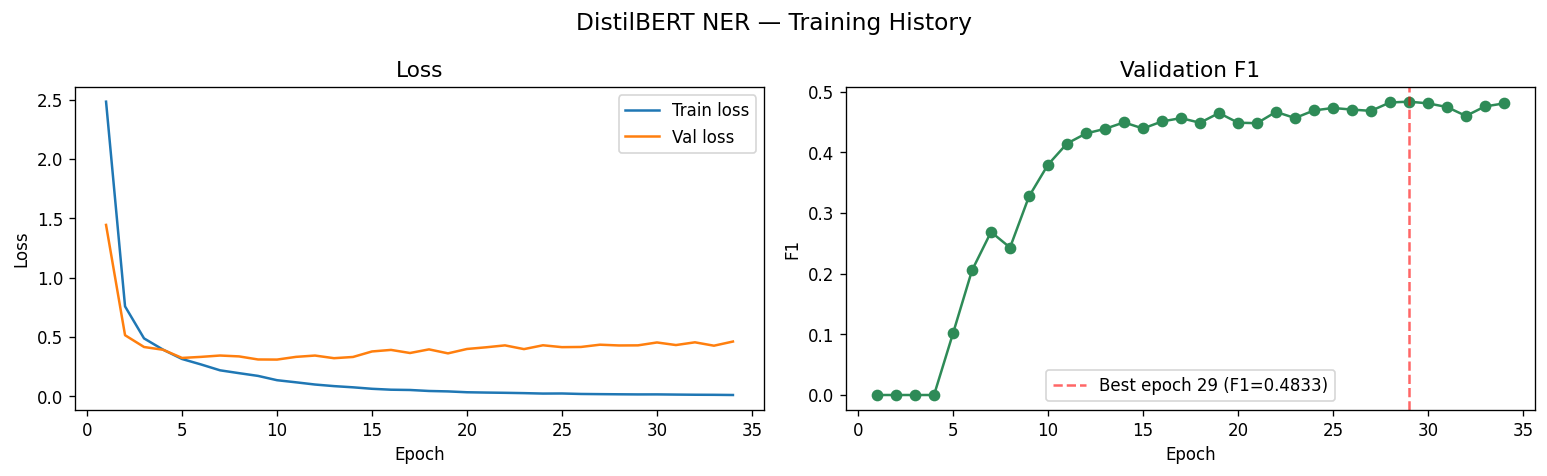

In [10]:
hist_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(hist_df['epoch'], hist_df['train_loss'], label='Train loss')
axes[0].plot(hist_df['epoch'], hist_df['val_loss'],   label='Val loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Loss'); axes[0].legend()

axes[1].plot(hist_df['epoch'], hist_df['val_f1'], color='seagreen', marker='o')
best_ep = hist_df.loc[hist_df['val_f1'].idxmax()]
axes[1].axvline(best_ep['epoch'], linestyle='--', color='red', alpha=0.6,
                label=f"Best epoch {int(best_ep['epoch'])} (F1={best_ep['val_f1']:.4f})")
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('F1')
axes[1].set_title('Validation F1'); axes[1].legend()

plt.suptitle('DistilBERT NER — Training History', fontsize=14)
plt.tight_layout()
plt.show()

### Evaluate on Test Set

In [11]:
# Load best checkpoint
model.load_state_dict(torch.load(BEST_CKPT, map_location=DEVICE))
model.eval()

y_test_all, y_pred_all = [], []
with torch.no_grad():
    for batch in test_loader:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        outputs = model(**batch)
        yt, yp = decode_preds(outputs.logits, batch['labels'], id2label)
        y_test_all.extend(yt)
        y_pred_all.extend(yp)

print('=== Test Set Evaluation (seqeval — entity-level) ===')
print(classification_report(y_test_all, y_pred_all, digits=4))

=== Test Set Evaluation (seqeval — entity-level) ===
                     precision    recall  f1-score   support

       College Name     0.3284    0.5366    0.4074        41
Companies worked at     0.3200    0.3596    0.3386        89
             Degree     0.4127    0.6667    0.5098        39
        Designation     0.3733    0.4308    0.4000        65
      Email Address     0.6471    0.9167    0.7586        24
    Graduation Year     0.4444    0.5333    0.4848        30
           Location     0.0000    0.0000    0.0000         5
               Name     0.8571    0.8824    0.8696        34
             Skills     0.0500    0.1389    0.0735        36
Years of Experience     1.0000    0.3333    0.5000         6

          micro avg     0.3553    0.4959    0.4140       369
          macro avg     0.4433    0.4798    0.4342       369
       weighted avg     0.4014    0.4959    0.4355       369



### Per-Entity Bar Chart

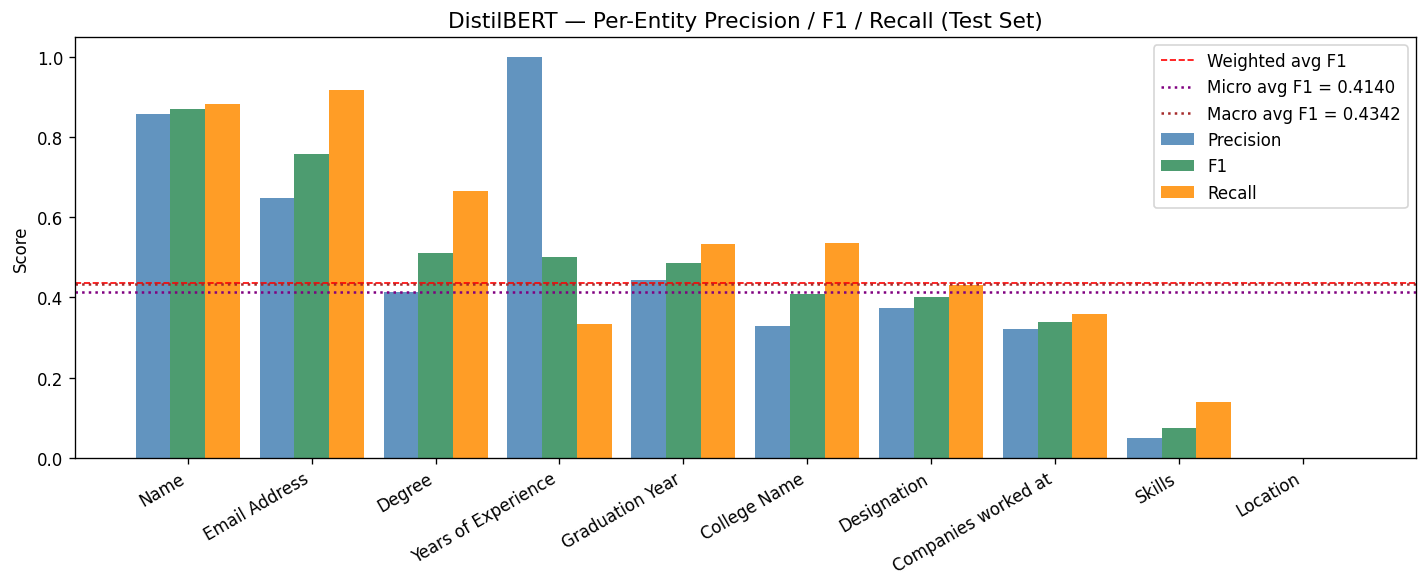

In [12]:
from seqeval.metrics import classification_report as seq_report

report_dict = seq_report(y_test_all, y_pred_all, digits=4, output_dict=True)

micro_f1 = report_dict['micro avg']['f1-score']
macro_f1 = report_dict['macro avg']['f1-score']

per_label = {
    k: v for k, v in report_dict.items()
    if isinstance(v, dict) and k not in ('micro avg', 'macro avg', 'weighted avg')
}

labels_sorted = sorted(per_label, key=lambda k: per_label[k]['f1-score'], reverse=True)
f1_scores_    = [per_label[k]['f1-score'] for k in labels_sorted]
precision_    = [per_label[k]['precision'] for k in labels_sorted]
recall_       = [per_label[k]['recall']    for k in labels_sorted]

fig, ax = plt.subplots(figsize=(12, 5))
x = range(len(labels_sorted))
w = 0.28
ax.bar([i - w for i in x], precision_, width=w, label='Precision', color='steelblue',  alpha=0.85)
ax.bar(list(x),            f1_scores_, width=w, label='F1',        color='seagreen',   alpha=0.85)
ax.bar([i + w for i in x], recall_,    width=w, label='Recall',    color='darkorange', alpha=0.85)
ax.set_xticks(list(x))
ax.set_xticklabels(labels_sorted, rotation=30, ha='right')
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('DistilBERT — Per-Entity Precision / F1 / Recall (Test Set)')
ax.axhline(report_dict.get('weighted avg', {}).get('f1-score', 0),
           color='red',    linestyle='--', linewidth=1,   label='Weighted avg F1')
ax.axhline(micro_f1, color='purple', linestyle=':',  linewidth=1.5,
           label=f'Micro avg F1 = {micro_f1:.4f}')
ax.axhline(macro_f1, color='brown',  linestyle=':',  linewidth=1.5,
           label=f'Macro avg F1 = {macro_f1:.4f}')
ax.legend()
plt.tight_layout()
plt.show()

### Inference Demo

In [13]:
import re

def predict_resume(text: str) -> list:
    words = text.split()
    enc = tokenizer(
        words,
        is_split_into_words=True,
        max_length=MAX_LEN_BERT,
        truncation=True,
        stride=128,
        return_overflowing_tokens=True,
        padding='max_length',
        return_tensors='pt',
    )

    all_results = {}
    for chunk_idx in range(len(enc['input_ids'])):
        chunk_input = {
            'input_ids'      : enc['input_ids'][chunk_idx].unsqueeze(0).to(DEVICE),
            'attention_mask' : enc['attention_mask'][chunk_idx].unsqueeze(0).to(DEVICE),
        }
        word_ids = enc.word_ids(chunk_idx)
        model.eval()
        with torch.no_grad():
            logits = model(**chunk_input).logits[0]
        pred_ids = logits.argmax(dim=-1).cpu().tolist()

        for wid, pid in zip(word_ids, pred_ids):
            if wid is None or wid in all_results:
                continue
            all_results[wid] = id2label[pid]  

    return [(words[wid], tag) for wid, tag in sorted(all_results.items())]


def extract_entities(predictions):
    """Group BIO-tagged tokens into entity strings by label."""
    entities = {}
    current_toks, current_lbl = [], None
    for tok, tag in predictions:
        if tag.startswith('B-'):
            if current_toks:
                entities.setdefault(current_lbl, []).append(' '.join(current_toks))
            current_toks, current_lbl = [tok], tag[2:]
        elif tag.startswith('I-') and current_toks:
            current_toks.append(tok)
        else:
            if current_toks:
                entities.setdefault(current_lbl, []).append(' '.join(current_toks))
            current_toks, current_lbl = [], None
    if current_toks:
        entities.setdefault(current_lbl, []).append(' '.join(current_toks))
    return entities


sample_tokens = subword_data[idx_test[0]]['tokens']
sample_text   = ' '.join(sample_tokens)
preds    = predict_resume(sample_text)
entities = extract_entities(preds)

print('Extracted Entities (Test Resume 0)')
for lbl, values in entities.items():
    print(f'[{lbl}]')
    for v in values:
        print(f'  • {v[:70]}')
    print()

Extracted Entities (Test Resume 0)
[Name]
  • dushyant bhatt

[Email Address]
  • indeed ##com/r/dushyant bhatt/140749dace5dc26f

[Companies worked at]
  • microsoft
  • microsoft

[Designation]
  • software engineer

[College Name]
  • saurashtra university

[Graduation Year]
  • 2007



### Save Model & Results

In [14]:
# Save tokenizer + model config alongside weights
tokenizer.save_pretrained(model_save_dir / 'distilbert_ner')
model.config.save_pretrained(model_save_dir / 'distilbert_ner')

# Save results in the same schema as results_crf.pkl
results = {
    'model'          : 'DistilBERT',
    'best_epoch'     : int(hist_df.loc[hist_df['val_f1'].idxmax(), 'epoch']),
    'val_f1'         : best_val_f1,
    'test_f1'        : f1_score(y_test_all, y_pred_all),
    'test_f1_micro'  : report_dict['micro avg']['f1-score'],
    'test_f1_macro'  : report_dict['macro avg']['f1-score'],
    'test_precision' : precision_score(y_test_all, y_pred_all),
    'test_recall'    : recall_score(y_test_all, y_pred_all),
    'y_test'         : y_test_all,
    'y_pred'         : y_pred_all,
    'idx_test'       : idx_test,
    'history'        : history,
}

with open(model_save_dir / 'results_distilbert.pkl', 'wb') as f:
    pickle.dump(results, f)

print('Model  saved -> model_result/distilbert_best.pt')
print('Config saved -> model_result/distilbert_ner/')
print('Results saved -> model_result/results_distilbert.pkl')
print()
print('Final DistilBERT Scores')
print(f"Val  F1       : {results['val_f1']:.4f}")
print(f"Test F1       : {results['test_f1']:.4f}")
print(f"Test Micro F1 : {results['test_f1_micro']:.4f}")
print(f"Test Macro F1 : {results['test_f1_macro']:.4f}")
print(f"Test Precision: {results['test_precision']:.4f}")
print(f"Test Recall   : {results['test_recall']:.4f}")

Model  saved -> model_result/distilbert_best.pt
Config saved -> model_result/distilbert_ner/
Results saved -> model_result/results_distilbert.pkl

Final DistilBERT Scores
Val  F1       : 0.4833
Test F1       : 0.4140
Test Micro F1 : 0.4140
Test Macro F1 : 0.4342
Test Precision: 0.3553
Test Recall   : 0.4959


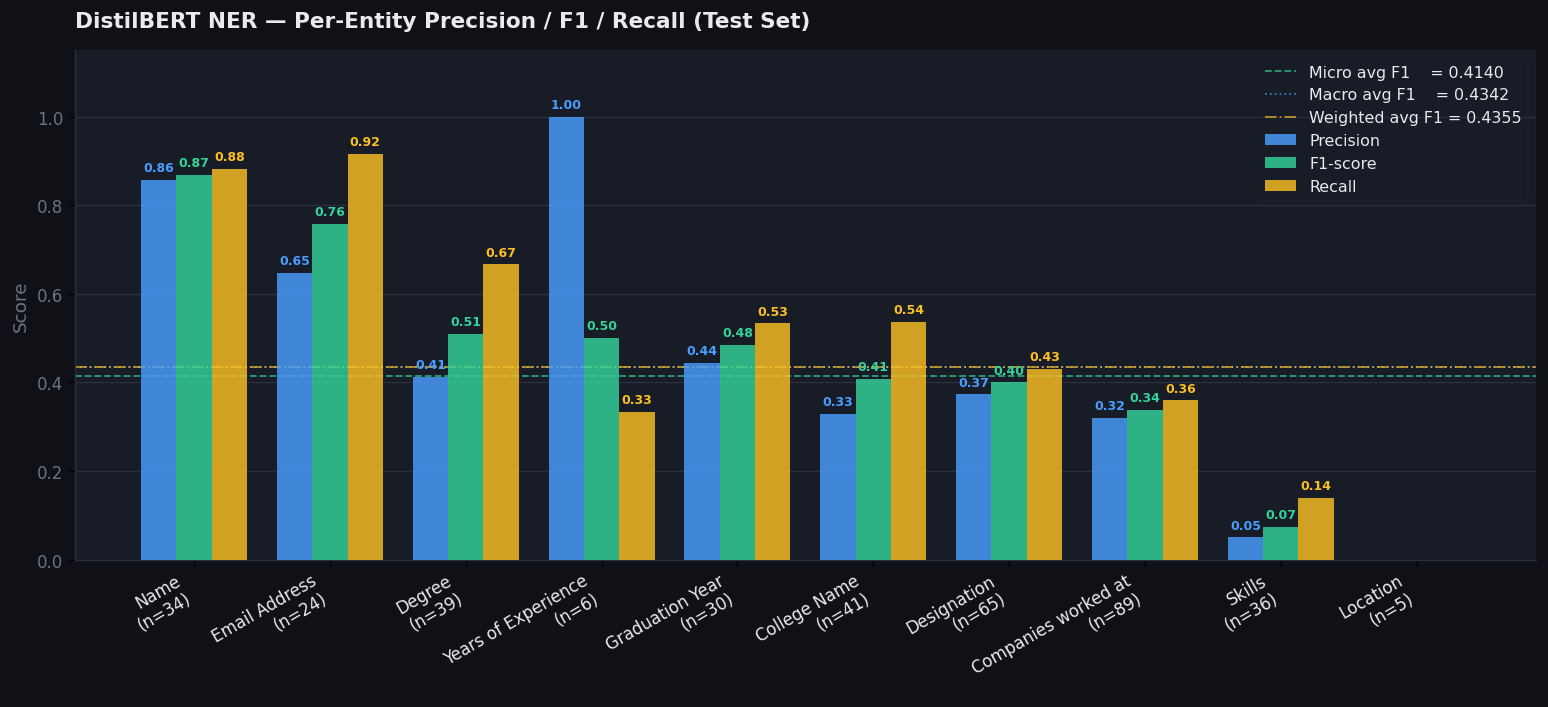

In [ ]:
from seqeval.metrics import classification_report as seq_report
import numpy as np

report_dict = seq_report(y_test_all, y_pred_all, digits=4, output_dict=True)

micro_f1    = report_dict['micro avg']['f1-score']
macro_f1    = report_dict['macro avg']['f1-score']
weighted_f1 = report_dict.get('weighted avg', {}).get('f1-score', 0)

per_label = {
    k: v for k, v in report_dict.items()
    if isinstance(v, dict) and k not in ('micro avg', 'macro avg', 'weighted avg')
}

# Sort by F1 descending
labels_sorted = sorted(per_label, key=lambda k: per_label[k]['f1-score'], reverse=True)
f1_scores_    = [per_label[k]['f1-score'] for k in labels_sorted]
precision_    = [per_label[k]['precision'] for k in labels_sorted]
recall_       = [per_label[k]['recall']    for k in labels_sorted]
support_      = [int(per_label[k]['support']) for k in labels_sorted]

n = len(labels_sorted)
x = np.arange(n)
w = 0.26

BG      = '#0f1117'
SURFACE = '#181c27'
BORDER  = '#2a2f3e'
MUTED   = '#6b7280'
TEXT    = '#e8eaf0'
COLOR_P = '#4a9eff'
COLOR_F = '#34d399'
COLOR_R = '#fbbf24'

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(SURFACE)

bars_p = ax.bar(x - w, precision_, width=w, color=COLOR_P, alpha=0.82, label='Precision', zorder=3)
bars_f = ax.bar(x,     f1_scores_, width=w, color=COLOR_F, alpha=0.82, label='F1-score',  zorder=3)
bars_r = ax.bar(x + w, recall_,    width=w, color=COLOR_R, alpha=0.82, label='Recall',    zorder=3)

# Value labels on top of each bar
for bars, color in [(bars_p, COLOR_P), (bars_f, COLOR_F), (bars_r, COLOR_R)]:
    for bar in bars:
        h = bar.get_height()
        if h > 0.02:
            ax.text(
                bar.get_x() + bar.get_width() / 2, h + 0.013,
                f'{h:.2f}', ha='center', va='bottom',
                fontsize=7.5, color=color, fontweight='bold',
            )


ax.set_xticks(x)
ax.set_xticklabels(
    [f'{lbl}\n(n={s})' for lbl, s in zip(labels_sorted, support_)],
    rotation=30, ha='right', fontsize=10, color=TEXT,
)

# Reference lines
ax.axhline(micro_f1,    color=COLOR_F, linestyle='--', linewidth=1.1, alpha=0.7,
           label=f'Micro avg F1    = {micro_f1:.4f}', zorder=2)
ax.axhline(macro_f1,    color=COLOR_P, linestyle=':',  linewidth=1.1, alpha=0.7,
           label=f'Macro avg F1    = {macro_f1:.4f}', zorder=2)
ax.axhline(weighted_f1, color=COLOR_R, linestyle='-.', linewidth=1.1, alpha=0.7,
           label=f'Weighted avg F1 = {weighted_f1:.4f}', zorder=2)

ax.set_ylim(0, 1.15)
ax.set_yticks(np.arange(0, 1.1, 0.2))
ax.set_yticklabels([f'{v:.1f}' for v in np.arange(0, 1.1, 0.2)], fontsize=10, color=MUTED)
ax.set_ylabel('Score', color=MUTED, fontsize=11)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_color(BORDER)
ax.tick_params(which='both')
ax.yaxis.grid(True, color=BORDER, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

ax.set_title(
    'DistilBERT NER — Per-Entity Precision / F1 / Recall (Test Set)',
    color=TEXT, fontsize=13, fontweight='bold', pad=14, loc='left',
)
ax.legend(
    loc='upper right', framealpha=0.15,
    facecolor=SURFACE, edgecolor=BORDER,
    labelcolor=TEXT, fontsize=9.5,
)

plt.tight_layout()
plt.show()